# Getaround - Machine learning

## Objectifs

- Suggérer des prix optimaux aux propriétaires de voitures grâce à l'apprentissage automatique

In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Lecture des fichiers
print("Loading dataset...")

__file__ = os.path.abspath("ML.ipynb")  # Simuler __file__ dans un notebook

# Définir le chemin absolu du modèle
dataset_path = os.path.join(os.path.dirname(__file__), '..', 'data', 'get_around_pricing_project.csv') 
dataset_path = os.path.normpath(dataset_path)
# os.path.dirname(__file__) permet de partir du dossier où se trouve app.py.
# .. remonte d’un niveau pour atteindre la racine du projet.

dataset_price = pd.read_csv(dataset_path, index_col=0)


#dataset_price = pd.read_csv("D:/Profils/NLefort/Desktop/JEDHA/PROJETS/08.Déploiement/data/get_around_pricing_project.csv", index_col=0)
print("...Done.")

Loading dataset...
...Done.


# Analyse descriptive

In [3]:
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes : {}".format(dataset_price.shape[0]))
print("Nombre de colonnes : {}".format(dataset_price.shape[1]))
print("Nombre de marques : {}".format(dataset_price['model_key'].nunique()))

print("Aperçu du dataset : ")
display(dataset_price.head())

print("Types de données/colonnes : ")
display(dataset_price.dtypes)



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes : 4843
Nombre de colonnes : 14
Nombre de marques : 28
Aperçu du dataset : 


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


Types de données/colonnes : 


model_key                    object
mileage                       int64
engine_power                  int64
fuel                         object
paint_color                  object
car_type                     object
private_parking_available      bool
has_gps                        bool
has_air_conditioning           bool
automatic_car                  bool
has_getaround_connect          bool
has_speed_regulator            bool
winter_tires                   bool
rental_price_per_day          int64
dtype: object

In [4]:
# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-"*40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset_price.isnull().sum()
missing_values_percentage = ((missing_values / dataset_price.shape[0]) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing_values,
    "Pourcentage": missing_values_percentage
})
print(missing_values.sum())


 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :
0


In [5]:
# STATISTIQUES DESCRIPTIVES

# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset_price.describe(include="all").round(2))

Statistiques descriptives globales :


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
count,4843,4843.00,4843.00,4843,4843,4843,4843,4843,4843,4843,4843,4843,4843,4843.00
unique,28,NaN,NaN,4,10,8,2,2,2,2,2,2,2,NaN
top,Citroën,NaN,NaN,diesel,black,estate,True,True,False,False,False,False,True,NaN
freq,969,NaN,NaN,4641,1633,1606,2662,3839,3865,3881,2613,3674,4514,NaN
mean,NaN,140962.80,128.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.21
std,NaN,60196.74,38.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.57
min,NaN,-64.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.00
25%,NaN,102913.50,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104.00
50%,NaN,141080.00,120.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119.00
75%,NaN,175195.50,135.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.00


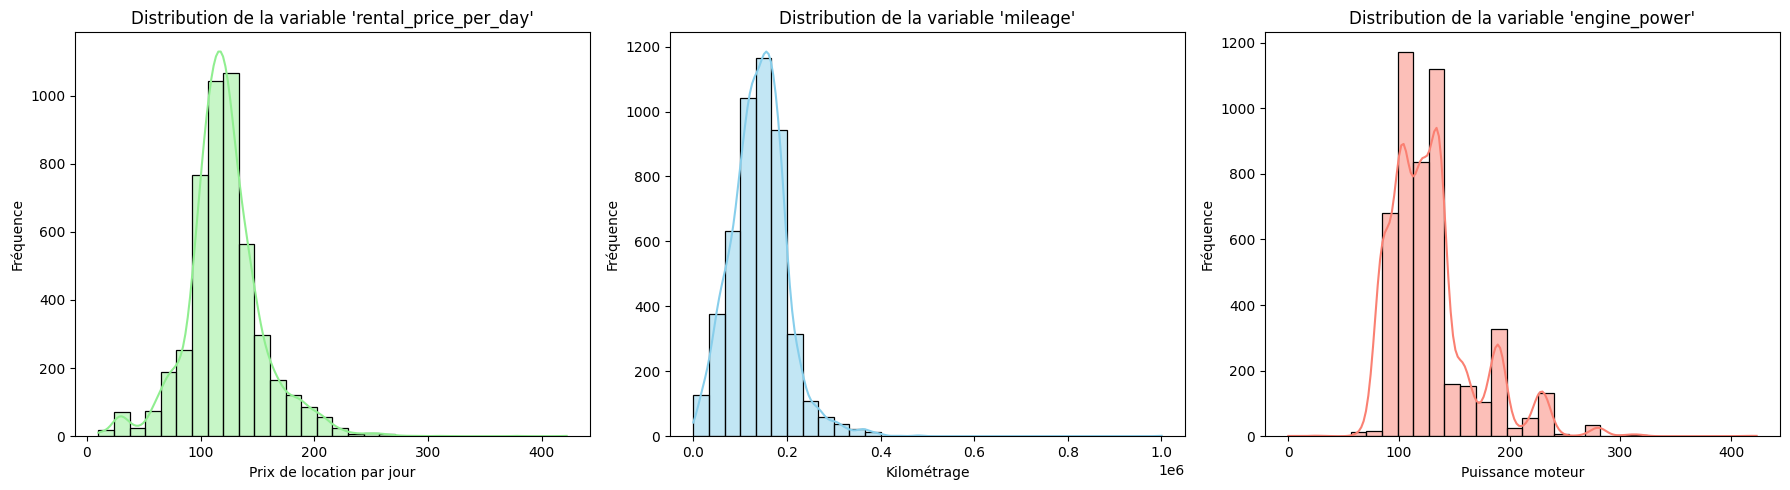

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Variable "rental_price_per_day"
sns.histplot(dataset_price['rental_price_per_day'].dropna(), bins=30, kde=True, ax=axes[0], color='lightgreen')
axes[0].set_title("Distribution de la variable 'rental_price_per_day'")
axes[0].set_xlabel("Prix de location par jour")
axes[0].set_ylabel("Fréquence")

# Variable "kilométrage"
sns.histplot(dataset_price['mileage'].dropna(), bins=30, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title("Distribution de la variable 'mileage'")
axes[1].set_xlabel("Kilométrage")
axes[1].set_ylabel("Fréquence")

# Variable "Puissance moteur"
sns.histplot(dataset_price['engine_power'].dropna(), bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title("Distribution de la variable 'engine_power'")
axes[2].set_xlabel("Puissance moteur")
axes[2].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()


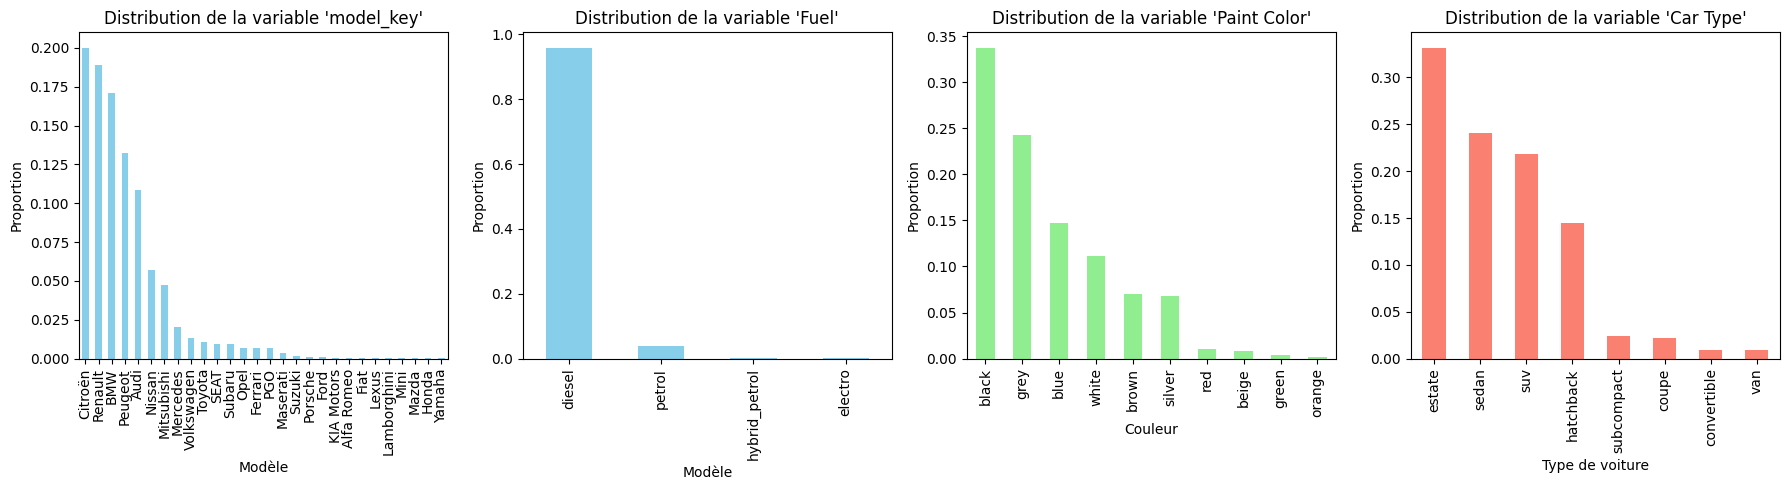

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18,5))

# Variable "Modèle"
dataset_price['model_key'].value_counts(normalize=True).plot.bar(ax=axes[0], color='skyblue')
axes[0].set_title("Distribution de la variable 'model_key'")
axes[0].set_ylabel("Proportion")
axes[0].set_xlabel("Modèle")

# Variable "fuel"
dataset_price['fuel'].value_counts(normalize=True).plot.bar(ax=axes[1], color='skyblue')
axes[1].set_title("Distribution de la variable 'Fuel'")
axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("Modèle")

# Variable "paint color"
dataset_price['paint_color'].value_counts(normalize=True).plot.bar(ax=axes[2], color='lightgreen')
axes[2].set_title("Distribution de la variable 'Paint Color'")
axes[2].set_ylabel("Proportion")
axes[2].set_xlabel("Couleur")

# Variable "car type"
dataset_price['car_type'].value_counts(normalize=True).plot.bar(ax=axes[3], color='salmon')
axes[3].set_title("Distribution de la variable 'Car Type'")
axes[3].set_ylabel("Proportion")
axes[3].set_xlabel("Type de voiture")

plt.tight_layout()
plt.show()

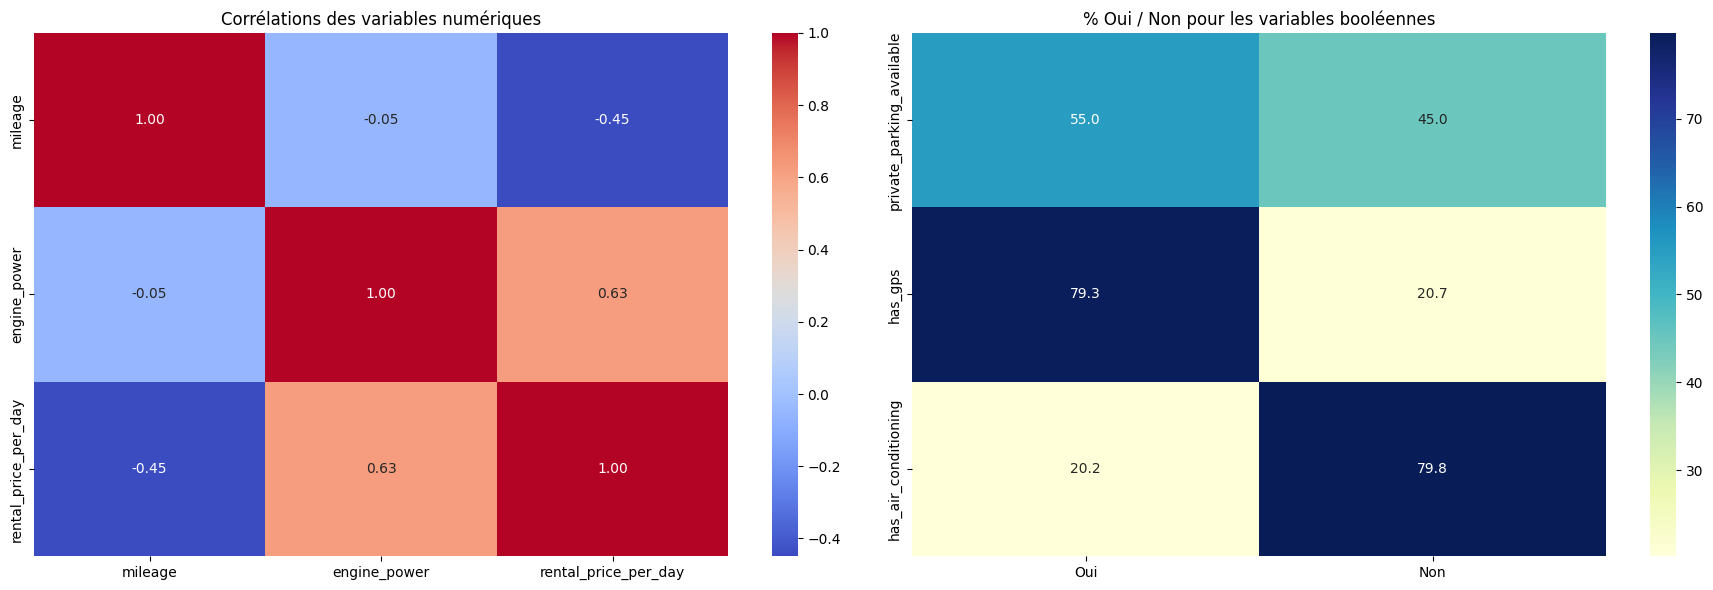

In [8]:

# ---------------------------
# Variables numériques continues
# ---------------------------
numeric_cols = dataset_price.select_dtypes(include=['int64', 'float64']).columns
corr_numeric = dataset_price[numeric_cols].corr()

# ---------------------------
# Variables booléennes
# ---------------------------
bool_cols = ['private_parking_available', 'has_gps', 'has_air_conditioning']  # adapter selon ton dataset
for col in bool_cols:
    dataset_price[col] = dataset_price[col].map({True:'Oui', False:'Non'})

bool_summary = pd.DataFrame({
    col: dataset_price[col].value_counts(normalize=True).mul(100).round(1)
    for col in bool_cols
}).T

bool_summary.columns = ['Non', 'Oui']  # vérifier ordre
bool_summary = bool_summary[['Oui','Non']]  # on préfère d'abord % Oui

# ---------------------------
# Figure combinée
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Heatmap variables numériques
sns.heatmap(corr_numeric, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0], cbar=True)
axes[0].set_title("Corrélations des variables numériques")

# Mini-heatmap pour booléennes (% Oui / Non)
sns.heatmap(bool_summary, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True, ax=axes[1])
axes[1].set_title("% Oui / Non pour les variables booléennes")

plt.tight_layout()
plt.show()


## Synthèse

* Moyenne de prix à 121 €/jour

On peut imaginer que les aspects suivants ont une influence plus ou moins forte sur le coût journalier de la location : 
* Effet vétusté : Plus le véhicule a un kilométrage élevé, plus cela a une incidence négative sur le prix de la location 
* Effet standing : Plus le véhicule est puissant, plus cela a une incidence positive sur le prix de la location. On peut supposer qu'une Citroën, citadine de couleur noire, d'une puissance moyenne de 130 ch sera dans les prix moyen.
* Effet équipement : On peut émettre une hypothèse selon laquelle plus un équipement est "rare" plus il peut avoir un petit effet sur le prix du véhicule. Ainsi, un GPS qui est un équipement commun (80% des véhicules en sont équipés) aura moins d'impact sur le prix qu'avoir l'air conditionné par exemple (pour lequel 80% des véhicules n'en sont pas équipés)


## Modèle de prédiction



In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, r2_score


### Modèles de base

In [10]:
# ========================
# Features et target
# ========================
target = 'rental_price_per_day'
X = dataset_price.drop(columns=[target])
y = dataset_price[target]

# ========================
# Séparation numériques / catégorielles
# ========================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

# ========================
# Preprocessing
# ========================
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ========================
# Modèles à tester
# ========================
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# ========================
# Boucle d'entraînement et évaluation
# ========================
results = []

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE (€)': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('RMSE (€)')
print(round(results_df, 2))


              Model  RMSE (€)    R2
3      RandomForest     16.72  0.73
4  GradientBoosting     17.04  0.72
0  LinearRegression     17.96  0.69
1             Ridge     17.97  0.69
2             Lasso     18.41  0.68


### Test sur modèle CatBoost

- Pourquoi CatBoost ?
  - Il gère nativement les variables catégorielles, donc pas besoin de OneHotEncoder ou TargetEncoder.
  - Il peut capturer des interactions complexes entre variables.
  - Souvent performant même sans hyperparamètres très finement réglés.

In [11]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split


# Séparer features / target
X = dataset_price.drop('rental_price_per_day', axis=1)
y = dataset_price['rental_price_per_day']

# Identifier les colonnes catégorielles
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialiser le modèle
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

# Entraîner
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), early_stopping_rounds=50)

# Prédictions
y_pred = model.predict(X_test)

# Évaluer
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} €")
print(f"R2: {r2:.2f}")


0:	learn: 32.0801129	test: 30.8175503	best: 30.8175503 (0)	total: 202ms	remaining: 3m 21s
100:	learn: 15.4035235	test: 16.7009204	best: 16.7009204 (100)	total: 5.67s	remaining: 50.5s
200:	learn: 14.2102917	test: 16.2702319	best: 16.2681410 (198)	total: 11.8s	remaining: 47s
300:	learn: 13.3212920	test: 16.1354499	best: 16.1354499 (300)	total: 17.5s	remaining: 40.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 16.13256448
bestIteration = 301

Shrink model to first 302 iterations.
RMSE: 16.13 €
R2: 0.75


Fitting 3 folds for each of 20 candidates, totalling 60 fits

🔍 Best Parameters found:
{'random_strength': 0.5, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 200, 'depth': 6, 'border_count': 64, 'bagging_temperature': 1}

✅ CatBoost optimisé - RMSE: 14.19 €
✅ R2: 0.82


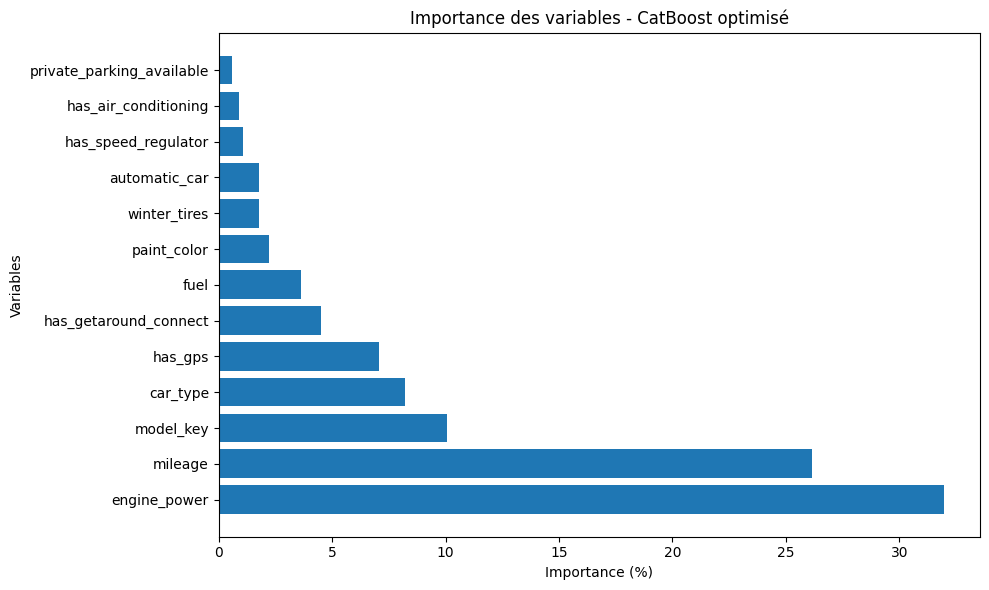

In [ ]:
# ------------------------------
# FINE TUNING CATBOOST
# ------------------------------
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Variables catégorielles
cat_features = dataset_price.select_dtypes(include=['object']).columns.tolist()

# Séparation features / target
X = dataset_price.drop(columns=['rental_price_per_day'])
y = dataset_price['rental_price_per_day']

# ------------------------------
# Paramètres à tester
# ------------------------------
param_grid = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 400, 600, 800],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128],
    'bagging_temperature': [0, 0.5, 1],
    'random_strength': [0.5, 1, 2]
}

# ------------------------------
# Modèle CatBoost de base
# ------------------------------
catboost_model = CatBoostRegressor(
    cat_features=cat_features,
    verbose=0,
    random_state=42
)

# ------------------------------
# Recherche aléatoire
# ------------------------------
random_search = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=param_grid,
    n_iter=20,           # nombre d’expérimentations — à augmenter pour une recherche plus fine
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entraînement
random_search.fit(X, y)

# ------------------------------
# Résultats
# ------------------------------
print("\n Best Parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

# Prédiction et évaluation
y_pred = best_model.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"\n CatBoost optimisé - RMSE: {rmse:.2f} €")
print(f" R2: {r2:.2f}")

# ------------------------------
# Feature importance
# ------------------------------
import matplotlib.pyplot as plt

feature_importance = best_model.get_feature_importance(prettified=True)
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature Id'], feature_importance['Importances'])
plt.title("Importance des variables - CatBoost optimisé")
plt.xlabel("Importance (%)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [ ]:
# Sauvegarde du modèle entraîné
best_model.save_model("catboost_pricing_model.cbm")
print(" Modèle CatBoost sauvegardé sous 'catboost_pricing_model.cbm'")

from catboost import CatBoostRegressor

# Chargement du modèle sauvegardé
loaded_model = CatBoostRegressor()
loaded_model.load_model("catboost_pricing_model.cbm")
print(" Modèle rechargé avec succès")


 Modèle CatBoost sauvegardé sous 'catboost_pricing_model.cbm'
✅ Modèle rechargé avec succès


## Prédiction personnalisée
### Test sur un modèle

In [26]:
# Exemple de véhicule (avec Oui/Non)
nouvelle_voiture = pd.DataFrame([{
    "model_key": "citroen",
    "mileage": 60000,
    "engine_power": 110,
    "fuel": "diesel",
    "paint_color": "black",
    "car_type": "sedan",
    "private_parking_available": "Oui",
    "has_gps": "Oui",
    "has_air_conditioning": "Oui",
    "automatic_car": "Non",
    "has_getaround_connect": "Oui",
    "has_speed_regulator": "Non",
    "winter_tires": "Oui"
}])

# Conversion Oui/Non en booléens
bool_map = {"Oui": True, "Non": False}
for col in ["private_parking_available", "has_gps", "has_air_conditioning", "automatic_car", "has_getaround_connect", "has_speed_regulator", "winter_tires"]:
    nouvelle_voiture[col] = nouvelle_voiture[col].map(bool_map)

# Prédiction
prix_prevu = loaded_model.predict(nouvelle_voiture)[0]
print(f" Prix estimé de location par jour : {prix_prevu:.2f} €")

# Fourchette indicative
marge = 0.11
prix_min, prix_max = prix_prevu * (1 - marge), prix_prevu * (1 + marge)
print(f" Fourchette estimée : {prix_min:.0f} € – {prix_max:.0f} € / jour")


 Prix estimé de location par jour : 147.01 €
 Fourchette estimée : 131 € – 163 € / jour


In [27]:
dataset_price.shape

(4843, 14)